# 🥇 Transformação Silver → Gold

Este notebook desenvolve a camada Gold da pipeline: lê as tabelas curadas da Silver e as modela para consumo analítico. É aqui que a pipeline passa a responder perguntas de negócio: qual a taxa de alfabetização de cada município nas três medidas da D-011, como a série histórica evolui quando o fluxo de 2025 entra na ponta, e quais municípios estão mais distantes das metas pactuadas. O resultado é gravado em `gold/`, a terceira área do medalhão, e exposto ao BigQuery por tabelas externas para consulta SQL.

> **Convenção de trabalho:** o desenvolvimento acontece neste notebook, célula a célula, com os resultados salvos. Ao final da etapa, o código estável é promovido para `src/transform/prod_04_silver_to_gold.py`.

**Decisões que governam este notebook** (ver [diário de decisões](../docs/decisoes.md)):
- D-005: a estimativa do fluxo vale apenas onde não há dado oficial, sempre identificada pela origem;
- D-010: a rede Pública (código 5) é o recorte de referência;
- D-011: dupla métrica por recorte: `taxa_oficial` (método INEP, presentes ponderados), `taxa_ajustada` (piso: ausentes como não alfabetizados) e `percentual_participacao`;
- D-012: motor pandas; BigQuery entra apenas no consumo, como tabelas externas sobre a Gold;
- D-013: metas na safra vigente estrita.

📚 **Referências das aulas (módulo Fase 2, Data Prepare):**
- *ETL Pipelines, Aula 1:* o papel da camada Gold (dados modelados para consumo, agregações e visões de negócio);
- *Cloud Data:* BigQuery como camada de consulta; tabelas externas sobre object storage;
- *Bancos de Dados Relacionais, Aula 1:* as chaves que sustentam os joins entre resultados, metas e dimensão.

---

**Estratégia de desenvolvimento deste notebook:**

```
inventário    ->  dupla métrica  ->  série histórica  ->  meta ×      ->  consumo     ->  ensaio da
da Silver         (D-011)            estoque + fluxo      resultado       (BigQuery)      produção
Seção 2           Seção 3            Seção 4              Seção 5         Seção 6         Seção 7
```

O princípio das etapas anteriores permanece: cada transformação é validada contra números conhecidos antes de avançar, e a gravação acontece uma única vez, ao final, com tudo conferido.

## 1. Setup do ambiente

**Passos desta seção:** ler a configuração do projeto, obter a credencial com o quota project declarado e definir os caminhos das camadas, com leitura da Silver por partição mais recente.

🎓 **Conceito** (*ETL Pipelines, Aula 1*): a Gold consome exclusivamente a Silver. Nenhuma célula deste notebook lê a Bronze: se um dado necessário não estiver na Silver, o caminho é evoluir a etapa anterior (como aconteceu com o diretório de municípios na etapa passada), nunca atravessar camadas.

> 📌 **Nota para reprodução:** este notebook lê o `config/config.json`, que não é versionado. Crie o seu a partir do `config/config.example.json`, como descrito na seção Como Executar do README. As camadas anteriores precisam existir no lake: execute `prod_01`, `prod_02` (publicar e consumir) e `prod_03` antes.

In [2]:
# --- 1.1 Configuração, credencial e caminhos das camadas ---
import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import pydata_google_auth
from google.cloud import storage

# Configuração do executor (projeto e bucket próprios)
CFG = json.loads(Path("../config/config.json").read_text(encoding="utf-8"))
PROJETO_GCP = CFG["projeto_gcp"]
BUCKET_LAKE = CFG["bucket_lake"]

# Credencial ampla com o quota project declarado (lição da etapa de streaming)
ESCOPOS = ["https://www.googleapis.com/auth/cloud-platform"]
credenciais = pydata_google_auth.get_user_credentials(ESCOPOS)
credenciais = credenciais.with_quota_project(PROJETO_GCP)

cliente_storage = storage.Client(project=PROJETO_GCP, credentials=credenciais)

SILVER = f"gs://{BUCKET_LAKE}/silver"
GOLD = f"gs://{BUCKET_LAKE}/gold"

def garantir_credencial() -> None:
    """Renova o token expirado e limpa o cache do gcsfs (sessões longas)."""
    import google.auth.transport.requests
    import gcsfs
    if not credenciais.valid:
        credenciais.refresh(google.auth.transport.requests.Request())
        gcsfs.GCSFileSystem.clear_instance_cache()

def ultima_particao(area: str, tabela: str) -> str:
    """Partição mais recente de uma tabela; erro orientado se não existir."""
    particoes = sorted({
        b.name.split("/")[2]
        for b in cliente_storage.list_blobs(BUCKET_LAKE, prefix=f"{area}/{tabela}/")
    })
    if not particoes:
        raise FileNotFoundError(
            f"Tabela '{tabela}' nao encontrada em {area}/. "
            "Execute a etapa anterior da pipeline (prod_03 para a Silver)."
        )
    return particoes[-1]

def ler_silver(tabela: str, **kwargs) -> pd.DataFrame:
    """Lê a partição mais recente de uma tabela da Silver."""
    garantir_credencial()
    caminho = (f"{SILVER}/{tabela}/{ultima_particao('silver', tabela)}/"
               f"{tabela}.parquet")
    return pd.read_parquet(caminho, storage_options={"token": credenciais}, **kwargs)

print(f"Origem:  {SILVER}/")
print(f"Destino: {GOLD}/")
print("Setup ok")

Origem:  gs://tech-challenge-fase2-lake-rm373453/silver/
Destino: gs://tech-challenge-fase2-lake-rm373453/gold/
Setup ok


## 2. Inventário da Silver: o contrato entre as camadas

**Passos desta seção:** conferir que as seis tabelas da Silver existem, com as contagens que a etapa anterior gravou e reconciliou.

🎓 **Conceito, confiar e conferir:** a Silver foi validada na etapa anterior, mas a Gold não assume nada: a primeira célula confere o inventário completo contra os números conhecidos (as mesmas contagens do resumo de execução do `prod_03`). Se alguém regravar a Silver com outra carga, esta célula denuncia a diferença antes que qualquer métrica seja calculada com dado inesperado. Note que a leitura da tabela de alunos usa apenas uma coluna: para contar linhas não é preciso trafegar as demais, e o formato Parquet (colunar) permite exatamente isso.

In [3]:
# --- 2.1 Conferir o inventário da Silver ---
INVENTARIO_ESPERADO = {
    "alunos":          3_866_814,
    "municipio":       23_995,
    "estimativa_2025": 1_163,
    "metas_brasil":    21,
    "metas_uf":        567,
    "metas_municipio": 74_928,
}

print("Inventário da Silver (partição mais recente):")
print()
divergencias = 0
for tabela, esperado in INVENTARIO_ESPERADO.items():
    # Uma coluna basta para contar (leitura colunar do Parquet)
    linhas = len(ler_silver(tabela, columns=["_processing_timestamp"]))
    status = "OK" if linhas == esperado else "DIVERGIU"
    divergencias += status != "OK"
    print(f"  {tabela:<18} {linhas:>10,} linhas  "
          f"(esperado {esperado:>10,})  {status}")

print()
print(f"Inventário: {'FALHA' if divergencias else 'OK'} "
      f"({len(INVENTARIO_ESPERADO) - divergencias} de {len(INVENTARIO_ESPERADO)})")

Inventário da Silver (partição mais recente):

  alunos              3,866,814 linhas  (esperado  3,866,814)  OK
  municipio              23,995 linhas  (esperado     23,995)  OK
  estimativa_2025         1,163 linhas  (esperado      1,163)  OK
  metas_brasil               21 linhas  (esperado         21)  OK
  metas_uf                  567 linhas  (esperado        567)  OK
  metas_municipio        74,928 linhas  (esperado     74,928)  OK

Inventário: OK (6 de 6)


## 3. Dupla métrica: as três medidas da D-011

**Passos desta seção:** (3.1) calcular, a partir dos microdados da Silver, as três medidas por município e ano no recorte da rede pública; (3.2) validar a taxa calculada contra a taxa oficial publicada, reproduzindo a verificação do levantamento das fontes.

🎓 **Conceito, as três medidas** (decisão D-011): cada recorte carrega três números que se explicam mutuamente:

- **`taxa_oficial`**: o método INEP, alunos presentes ponderados pelo peso amostral: `Σ(peso × alfabetizado) / Σ(peso)`. É a medida comparável com as publicações oficiais;
- **`percentual_participacao`**: quantos dos alunos avaliáveis fizeram a prova. É o denominador da confiança;
- **`taxa_ajustada`**: o cenário piso, com todos os ausentes contados como não alfabetizados: `taxa_oficial × participação`. A distância entre as duas taxas cresce onde a participação é baixa: é uma medida de incerteza, não uma segunda opinião.

📌 **Papel de cada fonte na Gold** (decisão D-005): a `taxa_oficial` publicada na Gold para 2023 e 2024 é a **da fonte** (tabela `municipio` da Silver), nunca a recalculada. O cálculo desta seção existe para derivar o que a fonte não publica (`taxa_ajustada` e `percentual_participacao`, que exigem microdados) e para **validar** o método: se a taxa calculada reproduz a oficial onde ambas existem, as derivadas herdam a credibilidade do método. Nos municípios do ponto cego (constam no consolidado sem microdados públicos), as derivadas ficam nulas, o nulo legítimo já conhecido.

In [4]:
# --- 3.1 Calcular as três medidas por município e ano (rede pública) ---
df_alunos = ler_silver(
    "alunos",
    columns=["ano", "id_municipio", "rede_nome", "presente",
             "alfabetizado", "peso_aluno"],
)

# Recorte comparável à rede Pública código 5 (D-010)
publica = df_alunos[df_alunos["rede_nome"].isin(["Estadual", "Municipal"])].copy()
print(f"Alunos no recorte da rede pública: {len(publica):,} "
      f"de {len(df_alunos):,}")

publica["alfabetizado_bin"] = publica["alfabetizado"].astype(str) == "1"
publica["peso_alfabetizado"] = (publica["peso_aluno"]
                                * publica["alfabetizado_bin"])

# Agregação: pesos nulos (ausentes) ficam fora das somas automaticamente
metricas = (publica.groupby(["ano", "id_municipio"])
            .agg(alunos_total=("presente", "size"),
                 alunos_presentes=("presente", "sum"),
                 soma_pesos=("peso_aluno", "sum"),
                 soma_pesos_alfabetizados=("peso_alfabetizado", "sum"))
            .reset_index())

metricas["percentual_participacao"] = (100 * metricas["alunos_presentes"]
                                       / metricas["alunos_total"])
metricas["taxa_oficial_calculada"] = (100 * metricas["soma_pesos_alfabetizados"]
                                      / metricas["soma_pesos"])
metricas["taxa_ajustada"] = (metricas["taxa_oficial_calculada"]
                             * metricas["percentual_participacao"] / 100)

print(f"Combinações município x ano: {len(metricas):,}")
print()
colunas_mostra = ["ano", "id_municipio", "alunos_total",
                  "percentual_participacao", "taxa_oficial_calculada",
                  "taxa_ajustada"]
print(metricas[colunas_mostra].head(5).round(2).to_string(index=False))

Alunos no recorte da rede pública: 3,866,789 de 3,866,814
Combinações município x ano: 10,392

 ano id_municipio  alunos_total  percentual_participacao  taxa_oficial_calculada  taxa_ajustada
2023      1100015           254                    89.37                   64.55          57.69
2023      1100023          1361                    89.79                   62.30          55.94
2023      1100031            84                    90.48                   69.10          62.52
2023      1100049           953                    85.31                   63.37          54.06
2023      1100056           241                    92.12                   58.53          53.92


In [5]:
# --- 3.2 Validar a taxa calculada contra a taxa oficial publicada ---
df_municipio = ler_silver("municipio")
oficial5 = df_municipio.loc[
    df_municipio["rede"].astype(str) == "5",
    ["ano", "id_municipio", "nome", "sigla_uf", "taxa_alfabetizacao"],
]

comparacao = oficial5.merge(metricas, on=["ano", "id_municipio"], how="left")
com_micro = comparacao[comparacao["taxa_oficial_calculada"].notna()].copy()
com_micro["diferenca"] = (com_micro["taxa_oficial_calculada"]
                          - com_micro["taxa_alfabetizacao"]).abs()

reproduzidas = (com_micro["diferenca"] <= 0.05).mean()
ponto_cego = comparacao["taxa_oficial_calculada"].isna().sum()

print(f"Municípios na tabela oficial (rede 5):     {len(comparacao):,}")
print(f"  com microdados correspondentes:          {len(com_micro):,}")
print(f"  sem microdados (ponto cego conhecido):   {ponto_cego:,}")
print()
print(f"Taxas reproduzidas (diferença <= 0,05 pp): {reproduzidas:.1%}")
print("(referência do levantamento das fontes: 95,8%)")
print()
print("Maiores divergências (regras oficiais não documentadas):")
print(com_micro.nlargest(3, "diferenca")
      [["ano", "nome", "sigla_uf", "taxa_alfabetizacao",
        "taxa_oficial_calculada", "diferenca"]]
      .round(2).to_string(index=False))

Municípios na tabela oficial (rede 5):     10,466
  com microdados correspondentes:          10,387
  sem microdados (ponto cego conhecido):   79

Taxas reproduzidas (diferença <= 0,05 pp): 95.1%
(referência do levantamento das fontes: 95,8%)

Maiores divergências (regras oficiais não documentadas):
 ano                 nome sigla_uf  taxa_alfabetizacao  taxa_oficial_calculada  diferenca
2023         Guaramiranga       CE               91.67                   55.61      36.06
2023 São João das Missões       MG               64.64                   45.92      18.72
2023               Silves       AM               40.10                   57.12      17.02


### 3.3 Leitura dos números da validação

- **95,1% reproduzidas** contra 95,8% do levantamento: a diferença vem do insumo, não do método. O cálculo agora parte da Silver, que quarentenou os 1.185 presentes sem nota; a referência do levantamento usava a Bronze completa.
- **Ponto cego de 79 combinações**, muito menor que os 643 municípios do levantamento: os grãos são diferentes. Os 643 contavam municípios de 2023 em **todas as redes** da tabela oficial sem microdados correspondentes; aqui a comparação usa apenas as linhas da **rede 5**, com o recorte Estadual + Municipal agregado, que encontra microdados para quase todos. No recorte que a Gold de fato usa, o ponto cego é residual.
- **As maiores divergências têm dezenas de pontos** (Guaramiranga/CE: 91,7 oficial contra 55,6 calculada): é o resíduo de ~5% documentado desde o levantamento, atribuído à base própria do INEP, mais completa que a pública. Por isso a `taxa_oficial` da Gold é sempre a da fonte (D-005); o cálculo próprio só sustenta as medidas derivadas.

## 4. Série histórica: o estoque encontra o fluxo

**Passos desta seção:** (4.1) montar a série do indicador municipal unindo o histórico oficial (batch, 2023 e 2024) com o ponto corrente estimado (streaming, 2025), com a origem explícita em cada linha; (4.2) conferir a série de municípios individuais.

🎓 **Conceito, a composição no eixo do tempo** (conceito documentado na Seção 6 da etapa Silver): o estoque (consolidados oficiais) e o fluxo (estimativa do ciclo em andamento) se compõem **na série histórica**, nunca dentro do mesmo ponto: cada ciclo avaliativo mede uma coorte nova e é autocontido. A coluna `origem` distingue as duas naturezas (`oficial_inep` × `estimativa_streaming`), e é ela que permite o ciclo de vida da D-005: quando o consolidado de 2025 for publicado, as linhas estimadas são substituídas pelas oficiais na recarga.

📌 **Assimetria declarada das colunas:** os pontos oficiais carregam as derivadas da Seção 3 (`taxa_ajustada`, `percentual_participacao`); o ponto estimado carrega `alunos_no_fluxo` (seu indicador de robustez amostral). Cada origem traz a incerteza que lhe cabe, e as colunas nulas na outra origem são o já conhecido nulo com significado.

In [6]:
# --- 4.1 Montar a série: estoque oficial + ponto estimado ---
# Estoque: taxa oficial da fonte + derivadas dos microdados (Seção 3)
estoque = oficial5.merge(
    metricas[["ano", "id_municipio", "percentual_participacao",
              "taxa_ajustada", "alunos_presentes"]],
    on=["ano", "id_municipio"], how="left",
).rename(columns={"taxa_alfabetizacao": "taxa"})
estoque["origem"] = "oficial_inep"

# Fluxo: estimativa 2025 da Silver (dimensão já incorporada)
fluxo = (ler_silver("estimativa_2025")
         .rename(columns={"taxa_estimada": "taxa"})
         [["ano", "id_municipio", "nome", "sigla_uf", "taxa",
           "alunos_no_fluxo", "origem"]])

serie_municipio = pd.concat([estoque, fluxo], ignore_index=True)

# Conferências: conservação e composição por origem
print(f"Estoque (oficial): {len(estoque):,}  |  Fluxo (estimado): {len(fluxo):,}")
print(f"Série completa:    {len(serie_municipio):,}  "
      f"(esperado: {len(estoque) + len(fluxo):,})")
print()
print(serie_municipio.groupby(["ano", "origem"]).size()
      .rename("linhas").reset_index().to_string(index=False))

Estoque (oficial): 10,466  |  Fluxo (estimado): 1,163
Série completa:    11,629  (esperado: 11,629)

 ano               origem  linhas
2023         oficial_inep    4950
2024         oficial_inep    5516
2025 estimativa_streaming    1163


In [7]:
# --- 4.2 A série de municípios individuais ---
# A razão de ser da tabela: a trajetória de um município através
# das duas naturezas de dado, com a origem sempre declarada.

colunas_serie = ["ano", "nome", "sigla_uf", "taxa", "origem",
                 "percentual_participacao", "alunos_no_fluxo"]

for id_mun, rotulo in [("3550308", "São Paulo"), ("2304400", "Fortaleza")]:
    trajetoria = (serie_municipio[serie_municipio["id_municipio"] == id_mun]
                  .sort_values("ano"))
    print(f"--- {rotulo} ---")
    print(trajetoria[colunas_serie].round(2).to_string(index=False))
    print()

--- São Paulo ---
 ano      nome sigla_uf  taxa               origem  percentual_participacao  alunos_no_fluxo
2023 São Paulo       SP 44.96         oficial_inep                      NaN              NaN
2024 São Paulo       SP 56.10         oficial_inep                    87.61              NaN
2025 São Paulo       SP 54.78 estimativa_streaming                      NaN            104.0

--- Fortaleza ---
 ano      nome sigla_uf  taxa               origem  percentual_participacao  alunos_no_fluxo
2023 Fortaleza       CE 74.16         oficial_inep                    93.88              NaN
2024 Fortaleza       CE 75.03         oficial_inep                    97.96              NaN
2025 Fortaleza       CE 82.77 estimativa_streaming                      NaN             23.0



## 5. Meta × resultado: a pergunta que a pipeline existe para responder

**Passos desta seção:** (5.1) integrar a série histórica com a meta da safra vigente e derivar as colunas de comparação; (5.2) responder a pergunta de negócio: quais municípios estão mais distantes das metas pactuadas; (5.3) visualizar a série com a meta.

🎓 **Conceito, a distância como métrica de priorização:** a comparação binária (atingiu ou não) esconde a informação que o gestor precisa: *quanto falta*. A coluna `distancia_meta` (taxa menos meta, em pontos percentuais) ordena os municípios por urgência e, cruzada com `percentual_participacao`, distingue dois problemas de natureza diferente: o município distante da meta com participação alta (problema de aprendizagem) e o distante com participação baixa (problema de medição antes de tudo, onde a taxa ajustada da D-011 mostra o piso do cenário).

📌 **A flag `atingiu_meta` tem três estados:** verdadeiro, falso e nulo. O nulo cobre os casos documentados da D-013 (2023 sem pactuação; municípios fora da safra vigente) e permanece nulo na estimativa de 2025: estimativa se compara com meta para acompanhamento (`distancia_meta` existe), mas o veredito oficial de atingimento só existe com dado oficial (D-005).

⚠️ **Atenção de execução:** a célula 5.1 modifica a `serie_municipio` (adiciona as colunas de meta) e não deve ser executada duas vezes em sequência; para repeti-la, execute antes a 4.1, que reconstrói a série. Na promoção para produção este passo vira função pura, eliminando o efeito colateral.

In [8]:
# --- 5.1 Integrar a meta vigente e derivar as colunas de comparação ---
metas_mun = ler_silver("metas_municipio")
safra_vigente = metas_mun["ano_referencia"].max()
metas_vigentes = metas_mun.loc[
    metas_mun["ano_referencia"] == safra_vigente,
    ["id_municipio", "ano_meta", "meta_taxa"],
]
print(f"Safra vigente das metas: {safra_vigente}")

antes = len(serie_municipio)
serie_municipio = serie_municipio.merge(
    metas_vigentes, left_on=["id_municipio", "ano"],
    right_on=["id_municipio", "ano_meta"], how="left",
).drop(columns="ano_meta")
print(f"Linhas antes/depois do join: {antes:,} / {len(serie_municipio):,}"
      f"  (esperado: igual)")

serie_municipio["distancia_meta"] = (serie_municipio["taxa"]
                                     - serie_municipio["meta_taxa"])
# Veredito oficial de atingimento: apenas com dado oficial E meta presente
com_veredito = ((serie_municipio["origem"] == "oficial_inep")
                & serie_municipio["meta_taxa"].notna())
serie_municipio["atingiu_meta"] = pd.NA
serie_municipio.loc[com_veredito, "atingiu_meta"] = (
    serie_municipio.loc[com_veredito, "taxa"]
    >= serie_municipio.loc[com_veredito, "meta_taxa"]
)

print()
print("Composição da flag atingiu_meta por ano:")
print(serie_municipio.groupby(["ano", "atingiu_meta"], dropna=False).size()
      .rename("linhas").reset_index().to_string(index=False))

Safra vigente das metas: 2024
Linhas antes/depois do join: 11,629 / 11,629  (esperado: igual)

Composição da flag atingiu_meta por ano:
 ano atingiu_meta  linhas
2023          NaN    4950
2024          NaN     284
2024        False    2415
2024         True    2817
2025          NaN    1163


In [9]:
# --- 5.2 A resposta: municípios mais distantes das metas (2024) ---
oficial_2024 = serie_municipio[
    (serie_municipio["ano"] == 2024)
    & serie_municipio["meta_taxa"].notna()
].copy()

atingiram = oficial_2024["atingiu_meta"].sum()
print(f"Municípios com meta em 2024: {len(oficial_2024):,}")
print(f"  atingiram a meta:     {atingiram:,} ({atingiram / len(oficial_2024):.1%})")
print(f"  não atingiram:        {len(oficial_2024) - atingiram:,}")
print()

colunas = ["nome", "sigla_uf", "taxa", "meta_taxa", "distancia_meta",
           "percentual_participacao"]
print("Os 10 municípios mais distantes da meta pactuada (2024):")
print(oficial_2024.nsmallest(10, "distancia_meta")[colunas]
      .round(2).to_string(index=False))

Municípios com meta em 2024: 5,232
  atingiram a meta:     2,817 (53.8%)
  não atingiram:        2,415

Os 10 municípios mais distantes da meta pactuada (2024):
            nome sigla_uf  taxa  meta_taxa  distancia_meta  percentual_participacao
           Sério       RS 11.10      80.00          -68.90                   100.00
 Arroio do Padre       RS 18.20      80.00          -61.80                    84.62
  Dona Francisca       RS 26.70      80.00          -53.30                    93.75
          Bozano       RS 27.30      80.00          -52.70                   100.00
     Nova Ramada       RS 28.00      80.00          -52.00                    96.15
  Monte do Carmo       TO 19.71      71.56          -51.85                    81.01
Sentinela do Sul       RS 23.50      74.77          -51.27                    85.71
Chapada de Areia       TO  6.25      54.93          -48.68                    76.19
        Marcação       PB 22.15      70.70          -48.55                    87.16

### 5.3 Visualização: a série e a meta no mesmo quadro

O gráfico materializa as convenções construídas até aqui: a linha cheia é o estoque oficial (batch), o trecho tracejado é o ponto corrente estimado pelo fluxo (streaming) e os traços cinza marcam a meta pactuada da safra vigente. A fronteira entre as duas naturezas de dado (D-005) fica visível no próprio traço: onde a linha vira tracejada, o dado deixou de ser oficial.

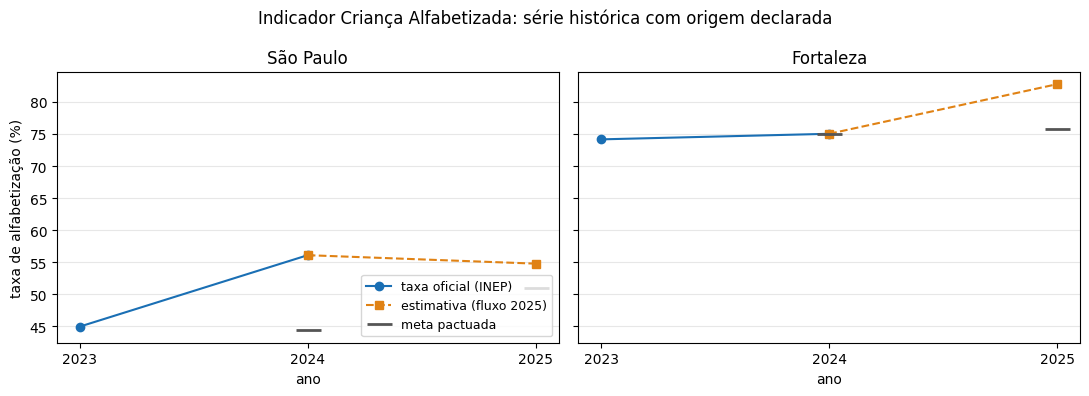

In [10]:
# --- 5.3 Trajetória do indicador: estoque, fluxo e meta ---
import matplotlib.pyplot as plt

MUNICIPIOS_DESTAQUE = {"3550308": "São Paulo", "2304400": "Fortaleza"}

fig, eixos = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for eixo, (id_mun, rotulo) in zip(eixos, MUNICIPIOS_DESTAQUE.items()):
    trajetoria = (serie_municipio[serie_municipio["id_municipio"] == id_mun]
                  .sort_values("ano"))
    oficial = trajetoria[trajetoria["origem"] == "oficial_inep"]
    estimado = trajetoria[trajetoria["origem"] == "estimativa_streaming"]

    # Estoque oficial: linha cheia
    eixo.plot(oficial["ano"], oficial["taxa"], marker="o",
              color="#1a6fb4", label="taxa oficial (INEP)")

    # Ponto estimado: tracejado, conectado ao último ponto oficial
    if len(estimado):
        ponte = pd.concat([oficial.tail(1), estimado])
        eixo.plot(ponte["ano"], ponte["taxa"], linestyle="--", marker="s",
                  color="#e08214", label="estimativa (fluxo 2025)")

    # Meta pactuada da safra vigente (traços; 2023 sem meta fica vazio)
    eixo.plot(trajetoria["ano"], trajetoria["meta_taxa"], linestyle="none",
              marker="_", markersize=18, markeredgewidth=2,
              color="#555555", label="meta pactuada")

    eixo.set_title(rotulo)
    eixo.set_xticks([2023, 2024, 2025])
    eixo.set_xlabel("ano")
    eixo.grid(axis="y", alpha=0.3)

eixos[0].set_ylabel("taxa de alfabetização (%)")
eixos[0].legend(loc="lower right", fontsize=9)
fig.suptitle("Indicador Criança Alfabetizada: série histórica com origem declarada")
plt.tight_layout()
plt.show()

## 6. Gravação e consumo: a Gold no lake, o SQL no BigQuery

**Passos desta seção:** (6.1) gravar a tabela analítica em `gold/` com reconciliação; (6.2) criar o dataset e a tabela externa no BigQuery; (6.3) responder a pergunta de negócio via SQL, fechando o ciclo.

🎓 **Conceito, tabela externa** (decisão D-012; *Cloud Data*): o dado permanece no lake, em Parquet; o BigQuery guarda apenas os metadados e lê os arquivos no momento da consulta. Consequências práticas: custo de armazenamento no BigQuery igual a zero (o dado não é duplicado), o lake segue como fonte única da verdade (D-006) e qualquer ferramenta com conector BigQuery (SQL, dashboards, modelos) consulta a Gold sem saber que ela mora num bucket.

📌 **Idempotência do consumo:** a tabela externa aponta para a **partição mais recente** da Gold. A recriação a cada carga é uma operação de metadados (barata e instantânea) que move o ponteiro para a partição nova, sem tocar nos dados. Reexecutar no mesmo dia produz o mesmo resultado.

📌 **O que a Gold entrega:** uma única tabela, `indicador_municipio`, com a série completa (2023, 2024 oficiais + 2025 estimado), as três medidas da D-011, a meta vigente e as colunas de comparação. Rankings e recortes são consultas sobre ela, não tabelas separadas: a Gold entrega o dataset que responde às perguntas, e cada consumidor faz a sua (o mesmo princípio anti-sobre-engenharia da D-012).

In [11]:
# --- 6.1 Gravar a tabela analítica na Gold, com reconciliação ---
# Tipagem explícita da flag de três estados para o Parquet
serie_municipio["atingiu_meta"] = serie_municipio["atingiu_meta"].astype("boolean")

def gravar_gold(df: pd.DataFrame, tabela: str) -> tuple[str, int]:
    """Grava uma tabela em gold/, particionada por data de processamento."""
    garantir_credencial()
    momento = datetime.now(timezone.utc)
    df = df.copy()
    df["_processing_timestamp"] = momento.isoformat()
    destino = (f"{GOLD}/{tabela}/data_processamento={momento:%Y-%m-%d}/"
               f"{tabela}.parquet")
    df.to_parquet(destino, index=False, storage_options={"token": credenciais})
    return destino, len(df)

destino, linhas = gravar_gold(serie_municipio, "indicador_municipio")
print(f"Gravado: {linhas:,} linhas")
print(f"Destino: {destino}")

# Reconciliação: o que está no lake é o que saiu da memória
relido = pd.read_parquet(destino, columns=["_processing_timestamp"],
                         storage_options={"token": credenciais})
status = "OK" if len(relido) == linhas else "DIVERGIU"
print(f"Reconciliação: relido {len(relido):,}  {status}")

Gravado: 11,629 linhas
Destino: gs://tech-challenge-fase2-lake-rm373453/gold/indicador_municipio/data_processamento=2026-07-12/indicador_municipio.parquet
Reconciliação: relido 11,629  OK


In [12]:
# --- 6.2 Expor a Gold ao BigQuery: dataset e tabela externa ---
from google.cloud import bigquery

cliente_bq = bigquery.Client(project=PROJETO_GCP, credentials=credenciais)

# Dataset da camada de consumo (idempotente), na mesma região do lake
dataset = bigquery.Dataset(f"{PROJETO_GCP}.gold")
dataset.location = CFG["regiao"]
cliente_bq.create_dataset(dataset, exists_ok=True)
print(f"Dataset pronto: {PROJETO_GCP}.gold  (região {CFG['regiao']})")

# Tabela externa apontando para a partição mais recente da Gold
particao = ultima_particao("gold", "indicador_municipio")
uri = f"{GOLD}/indicador_municipio/{particao}/*.parquet"

config_externa = bigquery.ExternalConfig("PARQUET")
config_externa.source_uris = [uri]
tabela_externa = bigquery.Table(f"{PROJETO_GCP}.gold.indicador_municipio")
tabela_externa.external_data_configuration = config_externa

# Recriar move o ponteiro para a partição vigente (operação de metadados)
cliente_bq.delete_table(tabela_externa, not_found_ok=True)
cliente_bq.create_table(tabela_externa)
print(f"Tabela externa criada sobre: {uri}")

Dataset pronto: tech-challenge-fase2.gold  (região us-central1)
Tabela externa criada sobre: gs://tech-challenge-fase2-lake-rm373453/gold/indicador_municipio/data_processamento=2026-07-12/*.parquet


In [13]:
# --- 6.3 Consumo: a pergunta de negócio respondida em SQL ---
import pandas_gbq

consulta = f"""
SELECT nome, sigla_uf, taxa, meta_taxa, distancia_meta,
       percentual_participacao
FROM `{PROJETO_GCP}.gold.indicador_municipio`
WHERE ano = 2024 AND meta_taxa IS NOT NULL
ORDER BY distancia_meta
LIMIT 5
"""

df_sql = pandas_gbq.read_gbq(consulta, project_id=PROJETO_GCP,
                             credentials=credenciais, progress_bar_type=None)

print("Resposta via SQL, direto do BigQuery (tabela externa sobre o lake):")
print(df_sql.round(2).to_string(index=False))
print()
print("Conferência: os mesmos 5 municípios do topo do ranking da célula 5.2.")

Resposta via SQL, direto do BigQuery (tabela externa sobre o lake):
           nome sigla_uf  taxa  meta_taxa  distancia_meta  percentual_participacao
          Sério       RS  11.1       80.0           -68.9                   100.00
Arroio do Padre       RS  18.2       80.0           -61.8                    84.62
 Dona Francisca       RS  26.7       80.0           -53.3                    93.75
         Bozano       RS  27.3       80.0           -52.7                   100.00
    Nova Ramada       RS  28.0       80.0           -52.0                    96.15

Conferência: os mesmos 5 municípios do topo do ranking da célula 5.2.


## 7. Da validação à produção

O ciclo validado neste notebook será promovido para `src/transform/prod_04_silver_to_gold.py`, seguindo a convenção D-008. O que muda na promoção:

- as células viram **funções puras** (métricas, série, integração de metas, gravação, publicação no BigQuery), orquestradas por um `main()` com relatório de execução no padrão dos scripts anteriores; o efeito colateral da célula 5.1, documentado no aviso da Seção 5, desaparece por construção;
- o **inventário da Seção 2 muda de natureza**: no desenvolvimento ele confere contagens exatas (validação contra números conhecidos); em produção ele confere a **existência** das tabelas da Silver, com mensagem orientando a executar o `prod_03`, porque as contagens legitimamente mudam a cada nova carga da fonte;
- a **visualização (célula 5.3) não é promovida**: gráfico é artefato de análise e documentação, não de pipeline; a produção entrega a tabela que permite a qualquer ferramenta desenhá-lo;
- as **verificações estruturais** (joins sem alteração de contagem, conservação da série, reconciliação da gravação) derrubam a execução com código de saída 1, o contrato que a orquestração da próxima etapa vai consumir.

As evidências de execução permanecem neste notebook; o script de produção referencia este desenvolvimento no cabeçalho.